In [25]:
import os
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [26]:
# Set visualisasi
sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None)

In [27]:
# Load konfigurasi parameter
with open("../config/config.yaml", "r") as file:
    config = yaml.safe_load(file)

print("Konfigurasi Sukses!")

path_aplikasi = "../" + config['directory']['raw_dataset_path']
df_train = pd.read_csv(path_aplikasi)
print(f"Data berhasil dimuat dengan ukuran: {df_train.shape}")

Konfigurasi Sukses!
Data berhasil dimuat dengan ukuran: (307511, 122)


In [28]:
# Distribusi riil variabel Target
target_counts = df_train[config['data_parameters']['target_column']].value_counts()
target_perc = df_train[config['data_parameters']['target_column']].value_counts(normalize=True) * 100

print(f"Analisis Distribusi Target:")
print(f"   - Nasabah Lancar (Target 0)      : {target_counts[0]:,} aplikasi ({target_perc[0]:.2f}%)")
print(f"   - Nasabah Gagal Bayar (Target 1) : {target_counts[1]:,} aplikasi ({target_perc[1]:.2f}%)")

Analisis Distribusi Target:
   - Nasabah Lancar (Target 0)      : 282,686 aplikasi (91.93%)
   - Nasabah Gagal Bayar (Target 1) : 24,825 aplikasi (8.07%)


In [29]:
# Cek nilai maksimum masa kerja dalam satuan HARI di dataset asli
# Cek kemungkinan adanya anomali Kolom DAYS_EMPLOYED
max_days_employed = df_train['DAYS_EMPLOYED'].max()
print(f"Hasil Investigasi Awal:")
print(f"   - Nilai maksimum DAYS_EMPLOYED di dataset asli : {max_days_employed} hari")
print(f"   - Setara dengan : {max_days_employed / 365.25:.1f} Tahun\n")

Hasil Investigasi Awal:
   - Nilai maksimum DAYS_EMPLOYED di dataset asli : 365243 hari
   - Setara dengan : 1000.0 Tahun



In [30]:
# Khusus kelompok anomali (Pensiunan/Pengangguran)
df_train['DAYS_EMPLOYED_ANOM'] = df_train['DAYS_EMPLOYED'] == 365243

/var/folders/m4/x0713fb11qdbv6bg4_r6t6t00000gn/T/ipykernel_6849/969076058.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_train['DAYS_EMPLOYED_ANOM'] = df_train['DAYS_EMPLOYED'] == 365243


In [31]:
# Ganti nilai anomali 365243 menjadi NaN agar distribusi LightGBM tree tidak rusak
df_train['DAYS_EMPLOYED'] = df_train['DAYS_EMPLOYED'].replace(365243, np.nan)

In [32]:
# Transformasikan data hari (negatif) menjadi satuan TAHUN (positif) agar masuk akal
df_train['AGE_YEARS'] = df_train['DAYS_BIRTH'] / -365.25
df_train['YEARS_EMPLOYED'] = df_train['DAYS_EMPLOYED'] / -365.25

print(df_train[['AGE_YEARS', 'YEARS_EMPLOYED', 'DAYS_EMPLOYED_ANOM']].describe())

           AGE_YEARS  YEARS_EMPLOYED
count  307511.000000   252137.000000
mean       43.906900        6.527500
std        11.947950        6.402081
min        20.503765       -0.000000
25%        33.984942        2.099932
50%        43.121150        4.511978
75%        53.886379        8.692676
max        69.073238       49.040383


/var/folders/m4/x0713fb11qdbv6bg4_r6t6t00000gn/T/ipykernel_6849/1774326029.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_train['AGE_YEARS'] = df_train['DAYS_BIRTH'] / -365.25
/var/folders/m4/x0713fb11qdbv6bg4_r6t6t00000gn/T/ipykernel_6849/1774326029.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_train['YEARS_EMPLOYED'] = df_train['DAYS_EMPLOYED'] / -365.25


In [33]:
#Untuk mencegah performa tidak lemot karena data yang too fragmented
df_train = df_train.copy()

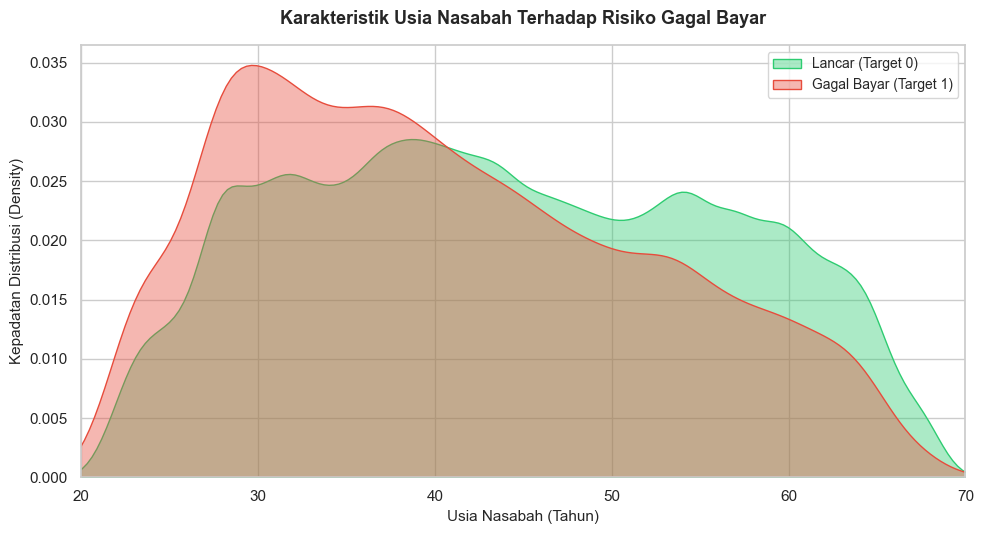

In [35]:
# Visualisasi Sebaran Umur Nasabah Berdasarkan Status Kelayakan Kredit
plt.figure(figsize=(10, 5.5))

# Kurva hijau untuk nasabah yang lancar (TARGET == 0)
sns.kdeplot(df_train.loc[df_train[config['data_parameters']['target_column']] == 0, 'AGE_YEARS'], 
            label='Lancar (Target 0)', fill=True, color='#2ecc71', alpha=0.4)

# Kurva merah untuk nasabah yang gagal bayar (TARGET == 1)
sns.kdeplot(df_train.loc[df_train[config['data_parameters']['target_column']] == 1, 'AGE_YEARS'], 
            label='Gagal Bayar (Target 1)', fill=True, color='#e74c3c', alpha=0.4)

plt.title('Karakteristik Usia Nasabah Terhadap Risiko Gagal Bayar', fontsize=13, pad=15, weight='bold')
plt.xlabel('Usia Nasabah (Tahun)', fontsize=11)
plt.ylabel('Kepadatan Distribusi (Density)', fontsize=11)
plt.xlim(20, 70)
plt.legend(fontsize=10, loc='upper right')
plt.tight_layout()
plt.show()

In [36]:
#push ke github
git add notebooks/1_eda_and_anomaly_detection.ipynb
git commit -m "Feature: Complete age vs target distribution visualization and analytical narrative"
git push origin main

SyntaxError: invalid decimal literal (962479834.py, line 2)